In [4]:
%load_ext autoreload
%autoreload 2

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras

from robot_vlp.config import EXTERNAL_DATA_DIR, MODELS_DIR

import robot_vlp.data.offline_path_navigation as pg

In [54]:
from robot_vlp.modeling.train_mlp import ang_loss_fn
mlp_model = keras.models.load_model(MODELS_DIR / 'model_01.keras',custom_objects={"ang_loss_fn": ang_loss_fn})
rnn_model = keras.models.load_model(MODELS_DIR / 'model_02.keras',custom_objects={"ang_loss_fn": ang_loss_fn})


In [7]:
vlp_dataset_path = EXTERNAL_DATA_DIR / "vlp_dataset.csv"
df = pd.read_csv(vlp_dataset_path, index_col=0)


vlp_model_dic = pg.read_vlp_models()
vlp_model = vlp_model_dic['high_acc']

In [2]:
import robot_vlp.robot as r

In [167]:
b = 6

In [168]:
f'asdf asdf {b}'

'asdf asdf 6'

In [12]:
r.get_vlp_pos_estimate(df, x = 2, y = 4,vlp_mod= vlp_model, k = 1)

(1.9862229397815547, 3.919925540472782)

In [25]:
xs = np.arange(1,5, 0.1)
ys = np.arange(1,5,0.1)

err_lst = []
for x in xs:
    for y in ys:
        pre = r.get_vlp_pos_estimate(df, x = x, y = y,vlp_mod= vlp_model, k = 1)
        pre_x = pre[0]
        pre_y = pre[1]
        err = np.sqrt(np.square(x-pre_x) + np.square(y-pre_y))
        err_lst.append(err)
errs = np.array(err_lst)
errs.mean()

0.10952716441624044

In [153]:
xs = np.arange(1,5, 0.1)
ys = np.arange(1,5,0.1)

err_lst = []
for x in xs:
    for y in ys:
        pre = r.get_vlp_pos_estimate(df, x = x, y = y,vlp_mod= vlp_model, k = 10, weight = False)
        pre_x = pre[0]
        pre_y = pre[1]
        err = np.sqrt(np.square(x-pre_x) + np.square(y-pre_y))
        err_lst.append(err)
errs = np.array(err_lst)
errs.mean()

0.0686000492169088

In [162]:
xs = np.arange(1,5, 0.1)
ys = np.arange(1,5,0.1)
def check_err(k):
    err_lst = []
    for x in xs:
        for y in ys:
            pre = r.get_vlp_pos_estimate(df, x = x, y = y,vlp_mod= vlp_model, k = k, weight = False)
            pre_x = pre[0]
            pre_y = pre[1]
            err = np.sqrt(np.square(x-pre_x) + np.square(y-pre_y))
            err_lst.append(err)
    errs = np.array(err_lst).mean()
    print('k: ',k," err: ",errs)
    return errs

k_lst = []
e_lst = []
for k in range(1,30):
    k_lst.append(k)
    e_lst.append(check_err(k))

k:  1  err:  0.10952716441624044
k:  2  err:  0.0892918442765114
k:  3  err:  0.08071379427102093
k:  4  err:  0.07656139650335593
k:  5  err:  0.07374633896073675
k:  6  err:  0.07215203084224994
k:  7  err:  0.07035464694080915
k:  8  err:  0.06970460160811691
k:  9  err:  0.0690804375009994
k:  10  err:  0.0686000492169088
k:  11  err:  0.06791201968946292
k:  12  err:  0.06737213070976303
k:  13  err:  0.06701137772668281
k:  14  err:  0.06670908973260216
k:  15  err:  0.06669548703286815
k:  16  err:  0.06647639804576384
k:  17  err:  0.0664219772740227
k:  18  err:  0.06596564291992067
k:  19  err:  0.06618159740124381
k:  20  err:  0.06612884264018712
k:  21  err:  0.06599164932120401
k:  22  err:  0.06597667564557813
k:  23  err:  0.0661141409973579
k:  24  err:  0.06629175411469297
k:  25  err:  0.0663921373275005
k:  26  err:  0.06628142658572647
k:  27  err:  0.06666779210509224
k:  28  err:  0.06696632838290029
k:  29  err:  0.06684816656869787


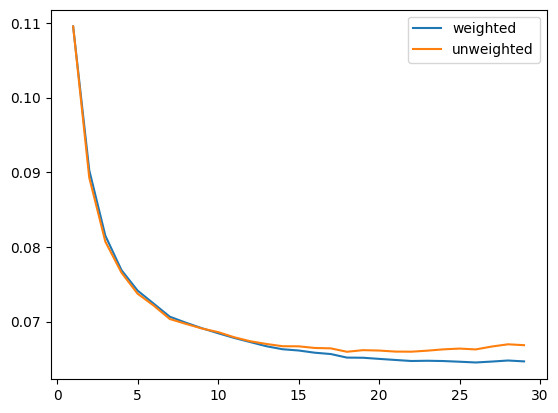

In [164]:
# w_k = k_lst
# w_e = e_lst
plt.plot(w_k, w_e, label = 'weighted')
plt.plot(k_lst, e_lst, label = 'unweighted')
plt.legend()

In [111]:
1/np.array([1,2,3,4])

array([1.        , 0.5       , 0.33333333, 0.25      ])

In [106]:
df.iloc[[1,2,9],:11]

,L1,L2,L3,L4,L5,L6,L7,L8,L9,L10,L11
index,,,,,,,,,,,
1,15.0,25.834706,40.269304,215.163688,53.172126,15.0,65.938937,314.402304,67.591192,35.151599,15.0
2,15.0,19.699516,43.623517,234.470798,43.794282,15.0,53.995155,331.835963,69.891430,28.650815,15.0
9,15.0,21.268998,39.999356,242.656925,45.041833,15.0,54.105370,334.441746,75.198227,31.538389,15.0


In [116]:
weights = [300000, 3, 3]
np.average(df.iloc[[1,2,9],:11].values, axis = 0, weights = weights).reshape(1,-1)

array([[ 15.        ,  25.83459887,  40.26933492, 215.16415582,
         53.17195091,  15.        ,  65.93869906, 314.40267878,
         67.59129115,  35.15149794,  15.        ]])

In [104]:
np.mean(df.iloc[[1,2,9],:11].values, axis = 0)

array([ 15.        ,  22.26774024,  41.29739229, 230.76380352,
        47.33608051,  15.        ,  58.01315385, 326.8933378 ,
        70.89361623,  31.78026759,  15.        ])

In [139]:
x = 3
y = 3

idx, dist = r.find_closest_index(df, x, y, 10)

In [132]:
idx

array([3011,  121, 1828, 4453, 4452, 6076, 2994, 4446,  127, 6084])

In [138]:
np.sqrt(np.square(df.iloc[idx,11] - 3) + np.square(df.iloc[idx,12] - 3))

index
3011    0.039640
121     0.115485
1828    0.134065
4453    0.130288
4452    0.128182
6076    0.140267
2994    0.141648
4446    0.142903
127     0.144334
6084    0.150873
dtype: float64

In [141]:
1/dist

index
3011    25.227338
121      8.659169
1828     7.459077
4453     7.675285
4452     7.801423
6076     7.129269
2994     7.059753
4446     6.997741
127      6.928364
6084     6.628077
dtype: float64